In [ ]:
from keras.preprocessing.image import img_to_array, load_img
from keras.applications.vgg16 import VGG16,preprocess_input
import numpy as np

model_vgg = VGG16(weights='imagenet', include_top=False)

def modelProcess(img_path, model):
    img = load_img(img_path, target_size=(224, 224))
    img = img_to_array(img)
    x = np.expand_dims(img, axis=0)
    x = preprocess_input(x)
    x_vgg = model.predict(x)
    x_vgg = x_vgg.reshape(1, 25088)
    return x_vgg

import os
folder = "猫狗数据集/dogs_cats/data/train/cats"
dirs = os.listdir(folder)

img_path = []
for i in dirs:
    if os.path.splitext(i)[1] == ".jpg":
        img_path.append(i)
img_path = [folder + "//" + i for i in img_path]

features1 = np.zeros([len(img_path), 25088])
for i in range(len(img_path)):
    feature_i = modelProcess(img_path[i], model_vgg)
    print('preprocessed:', img_path[i])
    features1[i] = feature_i

folder = "猫狗数据集/dogs_cats/data/train/dogs"
dirs = os.listdir(folder)
img_path = []
for i in dirs:
    if os.path.splitext(i)[1] == ".jpg":
        img_path.append(i)
img_path = [folder + "//" + i for i in img_path]
features2 = np.zeros([len(img_path),25088])
for i in range(len(img_path)):
    feature_i = modelProcess(img_path[i],model_vgg)
    print('preprocessed:',img_path[i])
    features2[i] = feature_i

print(features1.shape,features2.shape)

y1 = np.zeros(12499)
y2 = np.ones(12499)
X = np.concatenate((features1,features2),axis=0)
y = np.concatenate((y1,y2),axis=0)
y = y.reshape(-1,1)
print(X.shape,y.shape)

In [13]:
#ai优化版多图片卷积层预处理（多线程版）
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
import numpy as np
import os
from concurrent.futures import ThreadPoolExecutor  # 多线程加速图片加载

# ========== 步骤1：检查GPU并加载VGG16模型 ==========
print("可用GPU数量:", len(tf.config.list_physical_devices('GPU')))
# 显式指定GPU执行（确保模型在GPU上计算）
with tf.device('/GPU:0'):
    model_vgg = VGG16(weights='imagenet', include_top=False)


# ========== 步骤2：定义“批量处理图片+提取特征”的函数 ==========
def batch_extract_features(img_paths, model, batch_size):
    """
    批量处理图片，提取VGG16特征（利用多线程+批量推断加速）
    :param img_paths: 图片路径列表
    :param model: VGG16模型
    :param batch_size: 每次批量处理的图片数（需根据GPU显存调整）
    :return: 所有图片的特征数组，形状为 (图片总数, 25088)
    """
    all_features = []
    num_imgs = len(img_paths)
    
    # 分批次处理图片
    for start_idx in range(0, num_imgs, batch_size):
        end_idx = min(start_idx + batch_size, num_imgs)
        batch_paths = img_paths[start_idx:end_idx]
        
        # ---- 多线程加载并预处理当前批次的图片 ----
        with ThreadPoolExecutor(max_workers=24) as executor:
            # 多线程并行加载图片（IO密集型操作，多线程加速）
            imgs = list(executor.map(
                lambda path: load_img(path, target_size=(224, 224)), 
                batch_paths
            ))
        # 转换为数组并预处理
        imgs_array = np.array([img_to_array(img) for img in imgs])
        imgs_preprocessed = preprocess_input(imgs_array)
        
        # ---- 批量推断（GPU加速） ----
        with tf.device('/GPU:0'):
            batch_features = model.predict(imgs_preprocessed)  # verbose=0 关闭进度条
        
        # 调整特征形状（展平为一维）
        batch_features = batch_features.reshape(len(batch_paths), 25088)
        all_features.append(batch_features)
    
    # 合并所有批次的特征
    all_features = np.concatenate(all_features, axis=0)
    return all_features


# ========== 步骤3：处理“猫”图片，提取特征 ==========
folder_cats = "猫狗数据集/train/cats"
# 获取所有.jpg图片的路径，并按文件名排序（保证顺序可预期）
cats_paths = sorted([
    os.path.join(folder_cats, f) 
    for f in os.listdir(folder_cats) 
    if os.path.splitext(f)[1].lower() == ".jpg"
])[:300]
print(f"猫图片数量: {len(cats_paths)}")

# 批量提取猫的特征
features_cats = batch_extract_features(cats_paths, model_vgg, batch_size=32)
print(f"猫特征形状: {features_cats.shape}")

del cats_paths  # 删除图片路径列表（大列表，占内存）
import gc
gc.collect()  # 强制Python垃圾回收


# ========== 步骤4：处理“狗”图片，提取特征 ==========
folder_dogs = "猫狗数据集/train/dogs"
dogs_paths = sorted([
    os.path.join(folder_dogs, f) 
    for f in os.listdir(folder_dogs) 
    if os.path.splitext(f)[1].lower() == ".jpg"
])[:300]
print(f"狗图片数量: {len(dogs_paths)}")

# 批量提取狗的特征
features_dogs = batch_extract_features(dogs_paths, model_vgg, batch_size=32)
print(f"狗特征形状: {features_dogs.shape}")

del dogs_paths
gc.collect()


# ========== 步骤5：合并特征和标签，准备模型训练 ==========
# 生成标签（猫为0，狗为1）
labels_cats = np.zeros(features_cats.shape[0])
labels_dogs = np.ones(features_dogs.shape[0])

# 合并特征和标签
X = np.concatenate((features_cats, features_dogs), axis=0)
y = np.concatenate((labels_cats, labels_dogs), axis=0)
y = y.reshape(-1, 1)  # 调整为列向量

print(f"最终特征矩阵形状: {X.shape}")
print(f"最终标签形状: {y.shape}")

可用GPU数量: 1
猫图片数量: 300
1/1 [==============================] - 3s 3s/step
猫特征形状: (300, 25088)
狗图片数量: 300
1/1 [==============================] - 0s 15ms/step
狗特征形状: (300, 25088)
最终特征矩阵形状: (600, 25088)
最终标签形状: (600, 1)


In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=50)
print(x_train.shape,x_test.shape,X.shape)

(420, 25088) (180, 25088) (600, 25088)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
model=Sequential()
model.add(Input(shape=(25088,)))
model.add(Dense(units=10,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 10)                250890    
                                                                 
 dense_5 (Dense)             (None, 1)                 11        
                                                                 
Total params: 250901 (980.08 KB)
Trainable params: 250901 (980.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [16]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=50)

Epoch 1/50
14/14 [==============================] - 0s 3ms/step - loss: 3.9439 - accuracy: 0.7762
Epoch 2/50
14/14 [==============================] - 0s 3ms/step - loss: 0.2896 - accuracy: 0.9524
Epoch 3/50
14/14 [==============================] - 0s 3ms/step - loss: 0.2066 - accuracy: 0.9738
Epoch 4/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0032 - accuracy: 1.0000
Epoch 5/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0022 - accuracy: 1.0000
Epoch 6/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 7/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 8/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 9/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 10/50
14/14 [==============================] - 0s 3ms/step - loss: 0.0017 - accuracy: 1.0000
Epoch 11/50
14/14 [

In [17]:
from sklearn.metrics import accuracy_score
y_train_predict=(model.predict(x_train)>0.5).astype("int32")
accuracy_train=accuracy_score(y_train,y_train_predict)
print(accuracy_train)

14/14 [==============================] - 0s 2ms/step
1.0


In [18]:
y_test_predict=(model.predict(x_test)>0.5).astype("int32")
accuracy_test=accuracy_score(y_test,y_test_predict)
print(accuracy_test)

6/6 [==============================] - 0s 2ms/step
0.95


1/1 [==============================] - 0s 13ms/step


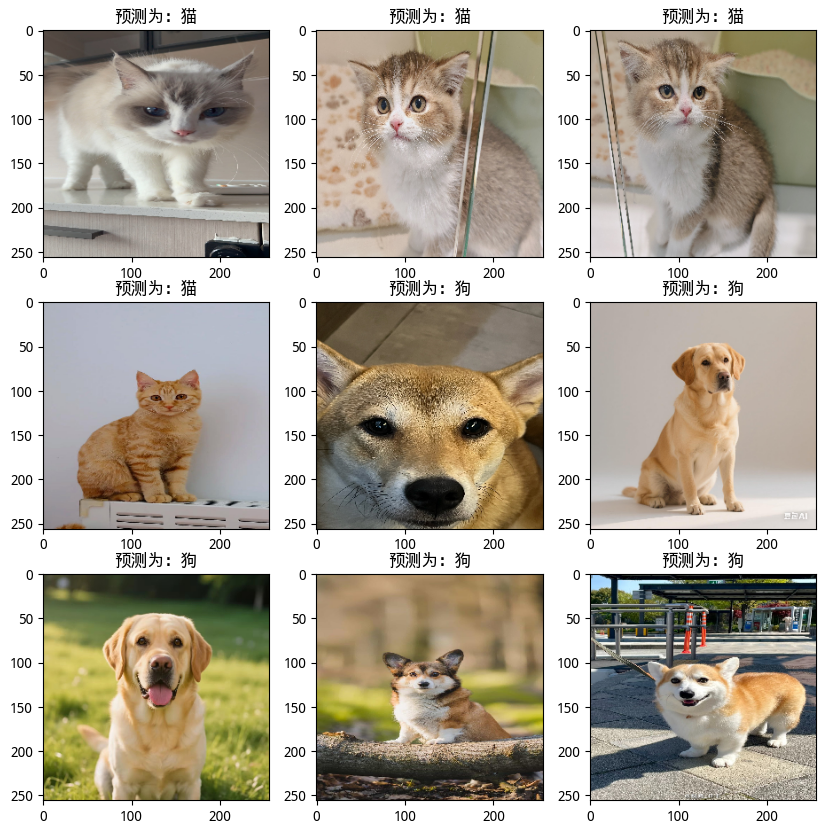

In [19]:
import matplotlib as mlp
font2={
    'family':'WenQuanYi Micro Hei',
    'weight':'normal',
    'size':20}
mlp.rcParams['font.family']='WenQuanYi Micro Hei'
mlp.rcParams['axes.unicode_minus']=False

from matplotlib import pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import load_img,img_to_array
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
import numpy as np

a=[i for i in range(1,10)]
fig=plt.figure(figsize=(10,10))
for i in a:
    img_path=str(i)+'.jpg'
    img=load_img(img_path,target_size=(224,224))
    img=img_to_array(img)

    x=np.expand_dims(img,axis=0)
    x=preprocess_input(x)
    features=model_vgg.predict(x)
    features=features.reshape(1,25088)
    
    result=(model.predict(features)>0.5).astype("int32")
    img_ori=load_img(img_path,target_size=(256,256))
    plt.subplot(3,3,i)
    plt.imshow(img_ori)
    plt.title('预测为：狗'if result[0][0]==1 else '预测为：猫')
plt.show()